<a href="https://colab.research.google.com/github/littlePanda2/ml-assignments/blob/main/assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 4: Density-based clustering

**Course:** WBCS032-05 Introduction to Machine Learning  
**Student Names: Sophie Schoerner**  
**Student Numbers: s4136594**  

---

## Assignment Overview

In this assignment, you will implement the Density-based spatial clustering of applications with noise (DBSCAN) algorithm as introduced and discussed in class, using Euclidean distance. Consider different settings for the parameter $minPts = 3,5,7$. Parameter eps will be optimised in the experiments. You will work with the same dataset `data_clustering.csv` used in Practical 2.


## 1. Introduction (1 point)

Describe the goal of this assignment. Your description should cover:

- The **problem** being solved
- The **experiments** performed
- The **algorithm** used
- The **dataset** used

**Your answer here:**

The goal of this assignment is to implement and evaluate the DBSCAN clustering algorithm.

The problem being solved is grouping unlabelled data points into clusters based on density, while automatically identifying noise points.

The algorithm used is DBSCAN, implemented through one driver function and two helper functions: dbscan, get_neighborhood_points, and expand_cluster.

The experiment is to tune the parameters neighborhood_radius and min_cluster_size by analyzing the KNN distance graph using plot_knn_distance, and visually evaluating the resulting clusters using plot_dbscan_clusters.

The dataset used is data_clustering.csv.

## 2. Methods (3.5 points)

### 2.1 Explain the DBSCAN algorithm (1 point)

Explain the algorithm in a general manner. Your explanation should describe all three components:
- **`DBSCAN`**: the main function - how it iterates over points and assigns cluster labels
- **`regionQuery`**: how it finds all neighbours within radius $\varepsilon$

- **`expand_cluster`**: how it grows a cluster from a core point

**Your answer here:**

DBSCAN is a clustering algorithm that groups points together based on how close and dense they are relative to each other, and treats isolated points as noise.

`DBSCAN` works by going through each point in the dataset and checking how many points are within a given radius ε. If a point has at least MinPts neighbors, it is considered a core point and a new cluster is started from it. If not, it is marked as noise.

`regionQuery` is a helper function that, given a point, returns all points within radius ε of it. It is used to determine whether a point is a core point or not.

`expand_cluster` grows the cluster from a core point by visiting all its neighbors and adding them to the cluster. If any of those neighbors are also core points, their neighbors are added too. This continues until there are no more points to add, at which point the cluster is complete.

### 2.2 Implementation (2.5 points)

You need to implement the DBSCAN algorithm **yourself**. Code and implementation itself will also be taken into account for the grading of this section.


*__Note:__* **Do not change the cell labels! Themis will use them to automatically grade your submission.**

In [ ]:
# Load required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import pathlib

# Data configuration
data_file_path = pathlib.Path("data_clustering.csv")

In [ ]:
# Read input data
df = pd.read_csv(data_file_path, header=None)
data = np.array(df)

In [ ]:
def dbscan(data_points, neighborhood_radius, min_cluster_size):
    """
    Density-based spatial clustering of applications with noise (DBSCAN)

    Args:
        data_points (ndarray): Data points to cluster.
        neighborhood_radius (float): The radius of the neighbourhood around a data point (epsilon).
        min_cluster_size (int): The minimum number of points required to form a dense region.

    Returns:
        cluster_labels (ndarray): The corresponding cluster label for each data point.
    """
    cluster_labels = np.full(data_points.shape[0], fill_value=-2)
    cluster_id = 1

    for point_index in range(data_points.shape[0]):
        if cluster_labels[point_index] != -2:
            continue

        neighboring_indices = get_neighborhood_points(data_points, point_index, neighborhood_radius)

        if min_cluster_size > len(neighboring_indices):
            cluster_labels[point_index] = -1
        else:
            cluster_labels[point_index] = cluster_id
            expand_cluster_2(data_points, cluster_labels, point_index, neighboring_indices, cluster_id, neighborhood_radius, min_cluster_size)
            cluster_id = cluster_id + 1

    return cluster_labels

def get_neighborhood_points(data_points, target_point_index, neighborhood_radius):
    """
    Return indices of all points within neighborhood_radius of target_point_index.

    Args:
        data_points (ndarray): Data points.
        target_point_index (int): The index of the point to query around.
        neighborhood_radius (float): The radius of the neighbourhood around a data point.

    Returns:
        neighboring_indices (list): The indices of all points within neighborhood_radius of target_point_index.
    """
    nearest_neighbors = NearestNeighbors(radius=neighborhood_radius).fit(data_points)
    return nearest_neighbors.radius_neighbors([data_points[target_point_index]], return_distance=False)[0].tolist()


def expand_cluster_2(data_points, cluster_labels, target_point_index, neighboring_indices, cluster_id, neighborhood_radius, min_cluster_size):
    """
    Expand the cluster with cluster_id from the seed point target_point_index.

    Args:
        data_points (ndarray): Data points.
        cluster_labels (ndarray): The corresponding cluster label for each data point.
        target_point_index (int): The index of the seed point to expand the cluster from.
        neighboring_indices (list): The indices of all points within neighborhood_radius of target_point_index.
        cluster_id (int): The identifier of the cluster being expanded.
        neighborhood_radius (float): The radius of the neighbourhood around a data point.
        min_cluster_size (int): The minimum number of points required to form a dense region.
    """
    queue = neighboring_indices

    while queue:
        current_index = queue.pop()

        # Only process points that have not yet been assigned a cluster label
        if cluster_labels[current_index] == -2 or cluster_labels[current_index] == -1:
            cluster_labels[current_index] = cluster_id

            neighbors = get_neighborhood_points(data_points, current_index, neighborhood_radius)
            if min_cluster_size <= len(neighbors):
                queue.extend(neighbors)

# Function Aliases
def DBSCAN(D, eps, MinPts):
    return dbscan(D, eps, MinPts)

def regionQuery(D, point_idx, eps):
    return get_neighborhood_points(D, point_idx, eps)

def expand_cluster(D, labels, point_idx, neighbors, cluster_id, eps, min_samples):
    return expand_cluster_2(D, labels, point_idx, neighbors, cluster_id, eps, min_samples)

## 3. Experimental Results (3.5 points)

### 3.1 KNN graphs

*__Note:__* This section **is graded** by Themis.

Implement the function below to plot the $k$-nearest neighbour distance graph. Mark one possible elbow point on each plot to indicate the threshold value for parameter $\varepsilon$.

You can use `sklearn.neighbors.NearestNeighbors(n_neighbors=k)` for the k-nearest neighbour search/graph.


### 3.2 Clustering results

_**Note:**_ This section **is graded** by Themis.

Implement the function below to perform DBSCAN clustering and plot the resulting clusters and outliers, for the $\varepsilon$ and $minPts$ values found in 3.1.


In [ ]:
def plot_knn(D, k, y=None):
    """
    Plot the k-nearest neighbour distance graph.

    Args:
        D (ndarray): Data points.
        k (int): Number of nearest neighbours.
        y (float, optional): Threshold value for eps. If provided, draws a
                             horizontal dashed line at this value.
    """

    # fit NearestNeighbors
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(D)
    distances, indices = neighbors_fit.kneighbors(D)

    # Get distances to k-th neighbor and sort them
    k_distances = np.sort(distances[:, k-1])

    # plot
    plt.figure()
    plt.plot(k_distances)
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{k}-Nearest Neighbor Distance')
    plt.title(f'{k} Nearest Neighbor graph')


    # mark elbow point if y is provided
    if y is not None:
        plt.axhline(y=y, linestyle='--')
        plt.show()

    plt.show()

    return k_distances

# # a few examples
# for k in [3, 5, 7]:
#     plot_knn(data, k)

In [ ]:
def plot_db_scan(D, eps, k):
    """
    Perform DBSCAN and plot the resulting clusters.

    Args:
        D (ndarray): Data points.
        eps (float): The radius of the neighbourhood around a data point.
        k (int): The minimum number of points to form a dense region (MinPts).
    """
    DBSCAN_points = np.array(DBSCAN(D, eps, k))

    plt.figure()
    scatter = plt.scatter(D[:, 0], D[:, 1], c=DBSCAN_points, edgecolors='black')

    handles, labels = scatter.legend_elements()

    unique_clusters = np.unique(DBSCAN_points)

    def parse_label(l):
        text = l.replace('$', '').replace('\\mathdefault{', '').replace('}', '').replace('−', '-')
        return int(text)

    filtered_handles = [h for h, l in zip(handles, labels) if parse_label(l) in unique_clusters]
    filtered_labels = [l for l in labels if parse_label(l) in unique_clusters]


    plt.legend(filtered_handles, filtered_labels, title="Clusters", framealpha=0.95)

    plt.title(f'DBSCAN clustering with MinPt={k}, eps={eps}')
    plt.xlabel('First feature')
    plt.ylabel('Second feature')
    plt.show()





def plot_dbscan_clusters(data_points, neighborhood_radius, min_cluster_size):
    """
    Perform DBSCAN and plot the resulting clusters.

    Args:
        data_points (ndarray): Data points.
        neighborhood_radius (float): The radius of the neighbourhood around a data point.
        min_cluster_size (int): The minimum number of points required to form a dense region.
    """
    plot_db_scan(data_points, neighborhood_radius, min_cluster_size)



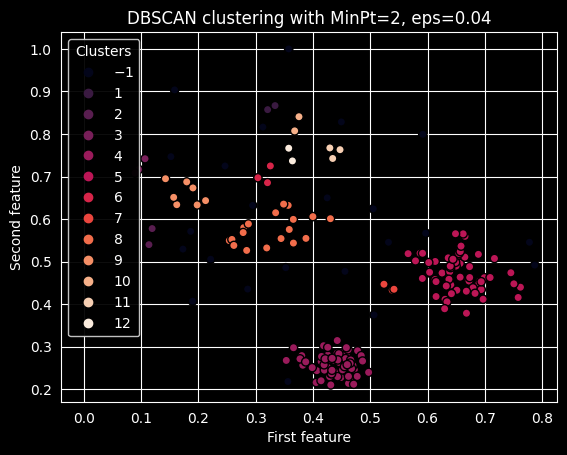

In [ ]:
plot_db_scan(
        D = data,
        eps = 0.04, # this is a random eps value, the true ones are for you to decide
        k = 2,
    )

### 3.3 Quantitative result

*__Note:__* This section **is not graded** by Themis.

Compute and return the silhouette score for the different parameter settings found in 3.1 (in total, 3 silhouette scores). You can use `sklearn.metrics.silhouette_score`.


In [ ]:
# Compute silhouette scores for the parameter settings found in section 3.1
# Replace eps_values and minpts_values with the values you determined

# we estimated these values from the plots from 3.1
minpts_values = [3, 5, 7]
eps_values = [0.05, 0.07, 0.10]

print(f"{'k (MinPts)':<10} | {'eps':<6} | {'Silhouette Score'}")
print("-" * 35)

for k, eps in zip(minpts_values, eps_values):
    labels = DBSCAN(data, eps, k)
    unique_labels = len(set(labels)) - (1 if -1 in labels else 0)
    if unique_labels > 1:
        score = silhouette_score(data, labels)
        print(f"{k:<10} | {eps:<6} | {score:.4f}")
    else:
        print(f"{k:<10} | {eps:<6} | not enough clusters")

k (MinPts) | eps    | Silhouette Score
-----------------------------------
3          | 0.05   | 0.4114
5          | 0.07   | 0.5668
7          | 0.1    | 0.4871


Fill in the silhouette scores obtained for each parameter setting:

| $k$ (MinPts) | $\varepsilon$ | Silhouette Score |
|:---:|:---:|:---:|
| 2 | | |
| 3 | | |
| 4 | | |

## 4. Discussion (2 points)

Discuss your observations on both the qualitative and quantitative results, and conclusions for the best choice of parameter settings.

**Your answer here:**


## Contribution

State your individual contribution.

**Your answer here:**

Sophie: Introduction,  2.1, 3.1

Mark: 2.2, 3.2, 3.3, 4